In [ ]:
from fits_io import scan_dataset, update_headers, dataset_metadata, object_in_fov
from fits_io import identify_objects, cleanup_intermediate_files 
from fits_io import flag_object_in_fov, load_dataset_objects
from reduccion import run_reduction, plot_reduction
from astrometria import run_astrometry
from stars_catalog import generate_refcat, plot_catalog_on_image
from combine import process_and_combine_images, plot_combined, remove_aligment_tempfiles, plot_alignment, plot_alignment_qc
import pandas as pd
from pathlib import Path
import os
from utils import load_config, Tee, load_target_coordinates, append_last_row
from datetime import datetime
import sys
from autophot.autophot_main import run_automatic_autophot
import tempfile
import shutil
from autophot.prep_input import load
from image_qc import run_image_qc, plot_qc_panel
import numpy as np




# -----------------------------------------------------------------------------
# Load settings
# -----------------------------------------------------------------------------

config_file="config.yaml"
cfg = load_config(config_file)

BASE = Path(cfg["paths"]["BASE"])
data_path = Path(BASE, cfg["paths"]["data_dir"])
object_path = Path(data_path, cfg["paths"]["objects_dir"])
night = cfg["night"]
night_dir = Path(data_path, night)
objects_csv = Path(object_path, "objetos.csv")
images_file_name = cfg["paths"]["images_data_file"]
images_file = Path(night_dir, images_file_name)


gain = cfg["instrument"]["gain"]
rdnoise = cfg["instrument"]["rdnoise"]

steps = cfg["steps"]

print(f"Running pipeline in night dir: {night_dir}")
# -------------------------------------------------------------------------
# Redirect stdout/stderr to a single log file (append)
# -------------------------------------------------------------------------
log_file = night_dir / "pipeline.log"
#sys.stdout = Tee(log_file)
#sys.stderr = sys.stdout

print("\n"*2 + "="*80)
print(f"New pipeline run: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)


# -------------------------------------------------------------------------
# 1) Scan dataset
# -------------------------------------------------------------------------
dataset = scan_dataset(night_dir)

# -------------------------------------------------------------------------
# 2) Update headers
# -------------------------------------------------------------------------
if steps.get("update_headers", False):
    print("→ Updating FITS headers")
    update_headers(dataset["all"], gain=gain, rdnoise=rdnoise)

# -------------------------------------------------------------------------
# 3) Export metadata
# -------------------------------------------------------------------------
if steps.get("export_metadata", False):
    print(f"→ Exporting metadata to {images_file}")
    metadata_file = dataset_metadata(dataset, night_dir, output_file=images_file,
                                         objects_csv=objects_csv)
    # Load objects list
    objects = load_dataset_objects(night_dir, images_file)
    
    # Create a folder in objects dir for each object
    for objname in objects:
        obj_dir = Path(object_path, objname)
        obj_dir.mkdir(parents=True, exist_ok=True)


# -------------------------------------------------------------------------
# 4) Reduction
# -------------------------------------------------------------------------
if steps.get("reduction", False):
    print("→ Running reduction")

    reduction_cfg = cfg.get("reduction", {})
    reduction_result = run_reduction(
        dataset=dataset,
        zero_correction=reduction_cfg.get("zero_correction", True),
        flat_correction=reduction_cfg.get("flat_correction", True),
        dark_correction=reduction_cfg.get("dark_correction", False),
    )
else:
    reduction_result = None
    
# -------------------------------------------------------------------------
# 4.a) Plot de reducción
# -------------------------------------------------------------------------
if cfg["qc"].get("reduction_images", False):
    print("→ [QC] Generating reduction plots")
    for objname in objects:
        print(f"   → Object: {objname}")

        plot_reduction(
            dataset=str(images_file),
            night_dir=night_dir,
            objname=objname,
            output_name=f"reduction_{objname}.png",
            show=False,
            overwrite=True
        )
    print("✓ [QC] Reduction plots generated")

# -------------------------------------------------------------------------
# 5) Astrometry
# -------------------------------------------------------------------------
if steps.get("astrometry", False):
    print("→ Running astrometry")

    astro_cfg = cfg.get("astrometry", {})
    run_astrometry(
        dataset=dataset,
        output_dir=night_dir,
        api_key=astro_cfg["api_key"],
        overwrite=astro_cfg.get("overwrite", True),
    )
    dataset = scan_dataset(night_dir)
    metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)

# -------------------------------------------------------------------------
# 5.a) Images contains its object?
# -------------------------------------------------------------------------
if steps.get("contains_obj", False):
    print("→ Flagging not contained images")
    df = flag_object_in_fov(metadata_file,
                       objects_csv,
                       night_dir,
                       overwrite=False)
    metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)
    
# -------------------------------------------------------------------------
# 5.b) Sanity check: filtro de imágenes válidas
# -------------------------------------------------------------------------
if steps.get("image_qc", False):
    print("→ Running image QC module")

    qc_cfg = cfg["qc"]["image_qc"]
    ds = pd.read_csv(images_file)

    mask = (
        ds["CALIBZ"].str.contains("bias", case=False, na=False) &
        (ds["ASTROMET"] == "yes") &
        ds["CALIBF"].str.contains("flat", case=False, na=False) &
        (ds["CONTAINS_OBJECT"] == True) &
        ds["FILENAME"].str.endswith("_wcs.fits")    
    )
    ds_filtered = ds[mask].copy()

    if ds_filtered.empty:
        print("   No images match QC criteria.")
    else:
        print(f"   Processing {len(ds_filtered)} images...")

    # Ensure QC columns exist
    qc_cols = ["QC_NSRCS", "QC_FWHM", "QC_ELLIP", "QC_USE", "QC_FLAGS", "QC_DATE"]
    for col in qc_cols:
        if col not in ds.columns:
            ds[col] = np.nan

    approved = rejected = 0

    for idx, row in ds_filtered.iterrows():
        fits_path = night_dir / row["FILENAME"]
        print(f"   → QC on {fits_path.name}")

        try:
            metrics, use, flags = run_image_qc(fits_path, qc_cfg, night_dir)

            ds.loc[idx, "QC_NSRCS"] = metrics.get("n_sources", np.nan)
            ds.loc[idx, "QC_FWHM"]   = metrics.get("fwhm", np.nan)
            ds.loc[idx, "QC_ELLIP"]  = metrics.get("ellipticity", np.nan)
            ds.loc[idx, "QC_USE"]    = use
            ds.loc[idx, "QC_FLAGS"]  = flags
            ds.loc[idx, "QC_DATE"]   = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

            status = "APPROVED" if use else "REJECTED"
            print(f"      {status} | n_src: {metrics.get('n_sources', 'N/A')}, "
                  f"FWHM: {metrics.get('fwhm', 'N/A'):.2f}, "
                  f"Ellip: {metrics.get('ellipticity', 'N/A'):.2f}, Flags: {flags}")

            if use:
                approved += 1
            else:
                rejected += 1
            
            if qc_cfg.get("plot", False):
                print(f"      → Plotting QC panel")
                plot_qc_panel(fits_path, night_dir/"qc_outputs"/f"{fits_path.stem}_cat.txt", metrics, night_dir/"qc_outputs")
                print(f"      QC panels saved in: {night_dir / 'qc_outputs'}/*.png")

        except Exception as e:
            print(f"      Error on {fits_path.name}: {str(e)}")
            ds.loc[idx, "QC_FLAGS"] = f"ERROR: {str(e)[:50]}..."
            rejected += 1

    ds.to_csv(images_file, index=False)
    print("      ✓ Image QC finished")

    # Summary
    total = approved + rejected
    rate = (approved / total * 100) if total > 0 else 0
    print(f"\nSummary: {total} processed | {approved} approved ({rate:.1f}%) | {rejected} rejected")

    if approved > 0:
        good = ds[ds["QC_USE"] == True]
        print(f"Median FWHM approved: {good['QC_FWHM'].median():.2f} px")
        print(f"Median n_sources approved: {good['QC_NSRCS'].median():.0f}")



# -------------------------------------------------------------------------
# 6) Combination
# -------------------------------------------------------------------------
if steps.get("combine", False):
    print("→ Combining images per object and filter")
    
    filters = cfg.get("filters", ["I", "V"])
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        # Load metadata for the object
        ra, dec = load_target_coordinates(objname, objects_csv)
        alig_cfg = cfg.get("aligment", {})["catalog"]
        # Load image path for the object
        ds = pd.read_csv(Path(night_dir, images_file))
        img_files = ds[(ds["OBJECT"]==objname)&(ds["ASTROMET"]=="yes")]["FILENAME"].values
        img_path = night_dir / img_files[0]

        alig_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=alig_cfg.get("fov_frac", 0.3),
            min_mag=alig_cfg.get("min_mag", 9),
            max_mag=alig_cfg.get("max_mag", 12),
            use_catalogs=alig_cfg.get("use_catalogs", "all"),
            plot=alig_cfg.get("plot", False),
            overwrite=alig_cfg.get("overwrite", False),
        )

        for filt in filters:
            print(f"      → Filter: {filt}")
            images_to_combine = [night_dir / im for im in img_files if im[-14].upper() == filt.upper()]
            if len(images_to_combine) == 0:
                print(f"         ! No images found for filter {filt}. Skipping.")
                continue
            print(f"         ✓ Found {len(images_to_combine)} images for filter {filt}.")
            combined_im = process_and_combine_images(images_to_combine, objname,  filt, object_path, night_dir, objects_csv)
            # Plot aligment reference catalog on combined images (unnecessary step)
            plot_catalog_on_image(fits_file=combined_im,
                                  catalog=alig_cat_path,
                                  obj_ra=ra,
                                  obj_dec=dec,
                                  out_png=Path(night_dir, f"{objname}{filt}_comb_alig_cat.png"),
                                  title=f"{objname} – Aligment catalog")
            if cfg["qc"].get("aligment_images", False):
                dataset = scan_dataset(night_dir)
                metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)
                print("      → [QC] Plotting aligment images")
                plot_alignment(
                    dataset=str(images_file),
                    night_dir=night_dir,
                    objname=objname,
                    filter_band=filt,
                    obj_ra=ra, obj_dec=dec,
                    output_name=f"aligment_{objname}.png",
                    show=False,
                    overwrite=True
                )
            if cfg["combine"].get("remove_temp_files", False):
                print("      → Removing temporary files")
                removed = remove_aligment_tempfiles(filt, night_dir)
    dataset = scan_dataset(night_dir)
    metadata_file = dataset_metadata(dataset, night_dir,
                                    output_file=images_file)
    

if cfg["qc"].get("combined_images", False):
    print("→ Generating combined plots")
    for objname in objects:
        print(f"   → Object: {objname}")
        image_files = [file for file in dataset["images_combined"] if objname in file.name]
        if len(image_files) == 0:
            print(f"      ! No combined images found for object {objname}. Skipping.")
            continue  
        plot_combined(objname, image_files,  night_dir, show=False)
        
        
if steps.get("photometry", False):
    print("→ Photometry on science images")
    phot_cfg = cfg["photometry"]
    img_files = []
    if phot_cfg["on_exp"]:
        img_files += dataset["images_astro"]
    if phot_cfg["on_comb"]:
        img_files += dataset["images_combined"]
         
    for objname in objects:
        print(f"   → Object: {objname}")
        print(f"      → Generating reference catalog")
        ra, dec = load_target_coordinates(objname, objects_csv)
        phot_cat_cfg = cfg["photometry"]["catalog"]
        img_path = night_dir / img_files[0]
        phot_cat_path = generate_refcat(
            objname=objname, ra_center=ra, dec_center=dec,
            img_path=img_path, objects_dir=object_path,
            fov_frac=phot_cat_cfg.get("fov_frac", 0.3),
            min_mag=phot_cat_cfg.get("min_mag", 9),
            max_mag=phot_cat_cfg.get("max_mag", 12),
            max_mag_err=phot_cat_cfg.get("max_mag_err", 0.25),
            use_catalogs=phot_cat_cfg.get("use_catalogs", False),
            plot=phot_cat_cfg.get("plot", False),
            type="phot",
            overwrite=phot_cat_cfg.get("overwrite", False)
        )
        print(f"      → [QC] Plotting catalog on combined image")
        combined_im = [f for f in dataset["images_combined"] if objname in f.name][0]
        plot_catalog_on_image(fits_file=combined_im,
                        catalog=phot_cat_path,
                        obj_ra=ra,
                        obj_dec=dec,
                        out_png=Path(object_path, objname, f"{objname}_phot_cat.png"),
                        title=f"{objname} – Aligment catalog")
        
        print("   → Photometry settings")
        image_files = []
        if phot_cfg["on_comb"]:
            image_files+=[f for f in dataset["images_combined"] if objname.lower() in str(f).lower()]
        if phot_cfg["on_exp"]:
            image_files+=[f for f in dataset["images_astro"] if objname.lower() in str(f).lower()]

        refcat_csv = os.path.join(BASE, "data", "objetos", objname, f"{objname}_phot_cat.csv")
        fits_dir = os.path.join(BASE, "data", night, objname, "phot")
        os.makedirs(fits_dir, exist_ok=True)
        for im in image_files:
            shutil.copy(im, Path(fits_dir, im.name))
        wdir = os.path.join(BASE, "outputs", night, objname)
        os.makedirs(wdir, exist_ok=True)

        #autophot_input = load()
        autophot_input = phot_cfg["autophot"]
        autophot_input["wdir"] = wdir
        autophot_input["fits_dir"] = fits_dir

        autophot_input["target_name"] = objname
        autophot_input["target_ra"] = ra/15
        autophot_input["target_dec"] = dec

        autophot_input["catalog"]["use_catalog"] = "custom"
        autophot_input["catalog"]["catalog_custom_fpath"] = refcat_csv
        shutil.copy("telescope.yml", Path(wdir, "telescope.yml"))

        try:
            run_automatic_autophot(autophot_input)
            os.chdir(BASE)
            print(f"         ✓ AutoPhOT completado para {objname}")
        except Exception as e:
            print(f"         Error AutoPhOT {objname}: {str(e)}")
            continue

        append_last_row(
            Path(night_dir, objname, "phot_REDUCED","REDUCED.csv"),
            Path(object_path, objname, "lightcurve.csv"),
            n_rows=len(image_files)
        )
        
        # Delete calibrated intermediate science images ? bias, flats
        # Delete duplicated images copied to run photometry?
 
print("✓ Pipeline finished successfully")


<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


Running pipeline in night dir: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis


New pipeline run: 2026-02-02 14:56:04
→ Exporting metadata to /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/images_data.csv


   Processing FITS files: 100%|██████████| 498/498 [00:00<00:00, 90087.27it/s]

→ Running image QC module
   Processing 100 images...
   → QC on FBOGLE-2025-BLG-0451v0001_wcs.fits


Catalog generated: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0001_wcs_cat.txt
      Detected objects: 944
      SNR_WIN - min: -1.86, max: 840.30, mean: 34.72, NaNs: 0
      Objects with FLAGS==0: 819
      Objects with SNR > 5: 939
      Objects good (FLAGS=0 and SNR>5): 814
      APPROVED | n_src: 814, FWHM: 4.00, Ellip: 0.09, Flags: 
      → Plotting QC panel
✓ Guardado: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0001_wcs_qc.png
      QC panels saved in: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/*.png
   → QC on FBOGLE-2025-BLG-0451v0002_wcs.fits
Catalog generated: /home/knowogrodski/Documentos/observation_HSH/ulens_hsh/ulens_hsh/data/20250823bis/qc_outputs/FBOGLE-2025-BLG-0451v0002_wcs_cat.txt
      Detected objects: 910
      SNR_WIN - min: -1.50, max: 832.30, mean: 34.98, NaNs: 0
      

In [3]:
metrics

{'n_sources': 1306, 'fwhm': 5.48, 'ellipticity': 0.235, 'background': 1022.762}

In [1]:
import re

qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for i in range(len(sex_cat)):
    path = sex_cat[i]
    # try to extract column names from the comment header (if present)
    with open(path, "r") as fh:
        header_text = "".join([ln for ln in fh if ln.startswith("#")])
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # read whitespace-separated SExtractor catalog; ignore comment lines
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                        names=col_names if col_names else None)

    # example: get 4th row values (same as .iloc[3].values)
    df_sex

    %matplotlib inline
    # buscar imagen correspondiente al catálogo (el nombre quitando "_cat.txt")
    from astropy.io import fits
    from astropy.visualization import ZScaleInterval, ImageNormalize
    import matplotlib.pyplot as plt

    image_base = path.name.replace("_cat.txt", ".fits")  # ej. 'FBOGLE-..._wcs'


    im_path = night_dir/image_base
    with fits.open(im_path) as hdul:
        data = hdul[0].data
    if data is None:
        print(f"No hay datos en {im_path}")
    else:
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]
        norm = ImageNormalize(data, interval=ZScaleInterval())
        plt.figure(figsize=(8, 8))
        plt.imshow(data, origin='lower', cmap='gray', norm=norm)
        # si hay columnas X_IMAGE/Y_IMAGE, dibujar fuentes
        if {'X_IMAGE', 'Y_IMAGE'}.issubset(df_sex.columns):
            plt.scatter(df_sex['X_IMAGE'], df_sex['Y_IMAGE'],
                        s=15, edgecolor='red', facecolor='none', linewidth=0.7)
        plt.title(f"Image: {im_path.name}")
        plt.colorbar(label='counts')
        plt.show()
        df_sex["ELLIPTICITY"].hist()
        med=df_sex["ELLIPTICITY"].median()
        mea = df_sex["ELLIPTICITY"].mean()
        plt.axvline(df_sex["ELLIPTICITY"].median(), color="r", label = f"median {med}")
        plt.axvline(df_sex["ELLIPTICITY"].mean(),color="k", label = f"mean {mea}")
        st = df_sex["ELLIPTICITY"].std()
        plt.title(f"ellipticity, std={st}")
        plt.legend()
        plt.show()
        df_sex[df_sex["FWHM_IMAGE"]>0]["FWHM_IMAGE"].hist()
        plt.title("fwhm")
        plt.show()

NameError: name 'night_dir' is not defined

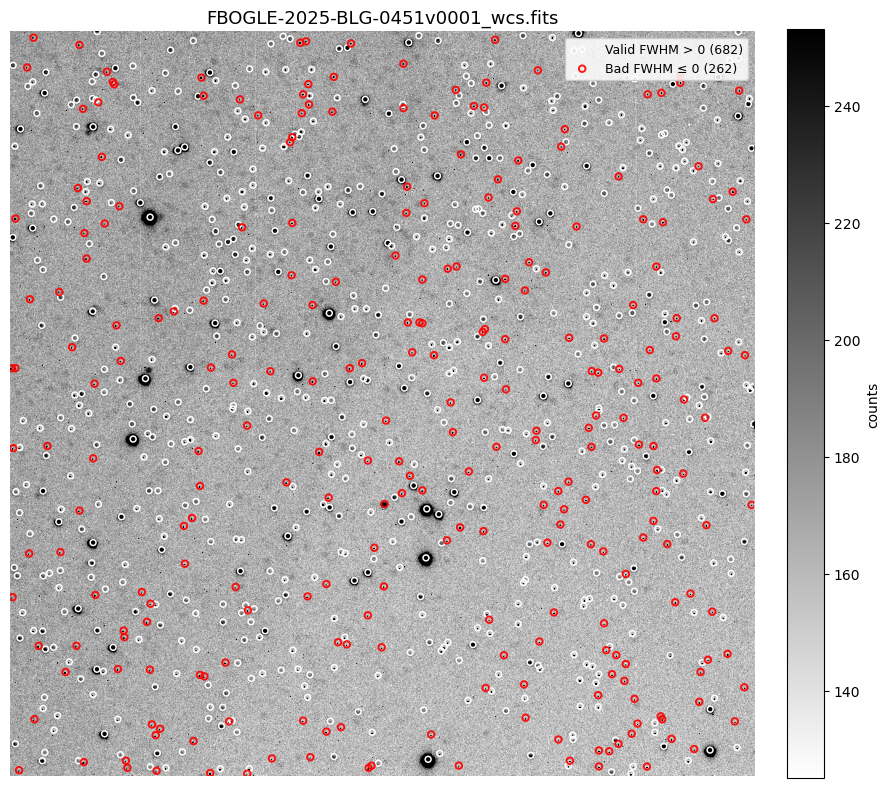

In [6]:
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import ZScaleInterval, ImageNormalize

# Suponiendo que night_dir ya está definido
qc_dir = night_dir / "qc_outputs"
sex_cat = sorted([qc_dir / f for f in os.listdir(qc_dir) if f.endswith("_cat.txt")])

for path in sex_cat:
    # ── Leer encabezado para nombres de columnas ─────────────────────────
    with open(path, "r") as fh:
        header_text = "".join(ln for ln in fh if ln.startswith("#"))
    col_names = re.findall(r"\d+\s+([A-Z0-9_]+)", header_text)

    # Leer catálogo SExtractor
    df_sex = pd.read_csv(path, delim_whitespace=True, comment="#", header=None,
                         names=col_names if col_names else None)

    if df_sex.empty:
        print(f"Catálogo vacío: {path.name}")
        continue

    # ── Buscar imagen correspondiente ─────────────────────────────────────
    image_base = path.name.replace("_cat.txt", ".fits")
    im_path = night_dir / image_base

    if not im_path.exists():
        print(f"No se encontró imagen: {im_path}")
        continue

    with fits.open(im_path) as hdul:
        data = hdul[0].data
        if data is None:
            print(f"No hay datos en {im_path}")
            continue
        data = data.squeeze()
        if data.ndim > 2:
            data = data[0]

    # Normalización
    norm = ImageNormalize(data, interval=ZScaleInterval())

    # ── Figura ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 9))

    ax.imshow(data, origin='lower', cmap='gray_r', norm=norm)
    ax.set_title(f"{im_path.name}", fontsize=13)
    ax.axis('off')

    # ── Dibujar fuentes con colores según FWHM ────────────────────────────
    if {'X_IMAGE', 'Y_IMAGE', 'FWHM_IMAGE'}.issubset(df_sex.columns):
        # Fuentes válidas (FWHM > 0) → blanco
        valid = df_sex[df_sex["FWHM_IMAGE"] > 0]
        ax.scatter(valid['X_IMAGE'], valid['Y_IMAGE'],
                   s=18, edgecolor='white', facecolor='none',
                   linewidth=1.1, label=f'Valid FWHM > 0 ({len(valid)})')

        # Fuentes problemáticas (FWHM ≤ 0) → rojo
        invalid = df_sex[df_sex["FWHM_IMAGE"] <= 0]
        if not invalid.empty:
            ax.scatter(invalid['X_IMAGE'], invalid['Y_IMAGE'],
                       s=22, edgecolor='red', facecolor='none',
                       linewidth=1.4, alpha=0.9,
                       label=f'Bad FWHM ≤ 0 ({len(invalid)})')

        ax.legend(loc='upper right', fontsize=9, framealpha=0.85)

    # Colorbar
    plt.colorbar(ax.imshow(data, origin='lower', cmap='gray_r', norm=norm),
                 ax=ax, fraction=0.046, pad=0.04, label='counts')

    plt.tight_layout()
    plt.show()
    break

In [9]:
df_sex[df_sex["FWHM_IMAGE"]<0]

,NUMBER,X_IMAGE,Y_IMAGE,FLUX_AUTO,FLUXERR_AUTO,MAG_AUTO,MAGERR_AUTO,FWHM_IMAGE,ELLIPTICITY,THETA_IMAGE,FLAGS,SNR_WIN,FLUX_APER,FLUXERR_APER
7,8,810.0002,12.0225,634.8639,63.79135,17.9933,0.1091,-13.57,0.016,-36.84,0,28.23,645.6196,39.84642
45,46,921.9534,962.9810,3325.4340,77.14017,16.1954,0.0252,-6.76,0.195,3.62,0,63.69,3091.7580,53.15167
97,98,411.0110,922.9969,921.5096,64.90500,17.5888,0.0765,-27.17,0.023,-45.20,0,38.09,1003.5330,42.03206
102,103,99.9919,917.0520,518.7411,63.33463,18.2126,0.1326,-6.76,0.052,-33.89,0,23.90,479.2642,38.88067
137,138,388.0134,878.0131,2724.4990,71.51331,16.4118,0.0285,-19.21,0.004,-69.66,0,67.80,2653.5250,50.90865
188,189,837.0258,824.0020,491.6120,68.64662,18.2709,0.1516,-13.57,0.021,32.81,0,17.52,369.2508,38.16674
226,227,569.8600,787.1475,253.2175,51.26283,18.9913,0.2199,-1.55,0.209,-48.73,0,13.16,249.3630,37.27746
260,261,129.8359,759.1742,253.3837,51.26365,18.9906,0.2197,-0.55,0.230,-47.79,0,10.42,194.0009,37.09745
334,335,448.0058,679.0157,763.0329,64.29168,17.7936,0.0915,-19.21,0.047,50.54,0,30.13,700.1284,40.18696
361,362,225.0327,638.2480,546.3260,93.11435,18.1564,0.1851,-1.55,0.035,64.88,3,16.26,364.2231,38.03997


Fuente encontrada → X=100.0, Y=917.1, FWHM=-6.76


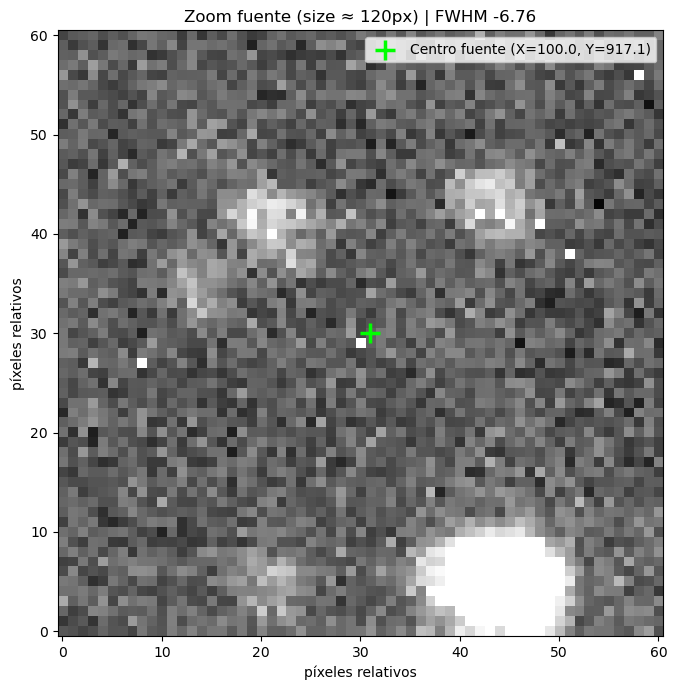

In [14]:
source = df_sex[df_sex['NUMBER'] == 103]
if source.empty:
    print("No se encontró la fuente")
else:
    x = source['X_IMAGE'].iloc[0]
    y = source['Y_IMAGE'].iloc[0]
    print(f"Fuente encontrada → X={x:.1f}, Y={y:.1f}, FWHM={source['FWHM_IMAGE'].iloc[0]:.2f}")

    # ── Parámetros del zoom ──────────────────────────────────────────
    zoom_size = 60          # radio en píxeles (tamaño total = 2*zoom_size)
    cutout_half = zoom_size // 2

    # Leer la imagen
    with fits.open(im_path) as hdul:
        data = hdul[0].data.astype(float).squeeze()

    # Recortar (con protección por bordes)
    x_int, y_int = int(x), int(y)
    x_min = max(0, x_int - cutout_half)
    x_max = min(data.shape[1], x_int + cutout_half + 1)
    y_min = max(0, y_int - cutout_half)
    y_max = min(data.shape[0], y_int + cutout_half + 1)

    cutout = data[y_min:y_max, x_min:x_max]

    # ── Graficar el zoom ─────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 7))

    norm = ImageNormalize(data, interval=ZScaleInterval())
    ax.imshow(cutout, origin='lower', cmap='gray', norm=norm)

    # Marcar el centro exacto (la posición real de la fuente)
    center_x = x - x_min
    center_y = y - y_min
    ax.scatter(center_x, center_y, s=200, marker='+', color='lime', linewidth=2.5,
               label=f"Centro fuente (X={x:.1f}, Y={y:.1f})")

    ax.set_title(f"Zoom fuente (size ≈ {zoom_size*2}px) | FWHM {source['FWHM_IMAGE'].iloc[0]:.2f}")
    ax.legend(loc='upper right', fontsize=10)
    ax.set_xlabel("píxeles relativos")
    ax.set_ylabel("píxeles relativos")

    # Opcional: agregar círculo con tamaño FWHM aproximado
    from matplotlib.patches import Circle
    fwhm = source['FWHM_IMAGE'].iloc[0]
    if fwhm > 0:
        circle = Circle((center_x, center_y), radius=fwhm/2, color='cyan', 
                        fill=False,
                        linewidth=1.8, linestyle='--', alpha=0.8,
                        label=f"FWHM/2 ≈ {fwhm/2:.1f} px")
        ax.add_patch(circle)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [4]:
df_sex[df_sex["FWHM_IMAGE"]<0]

,NUMBER,X_IMAGE,Y_IMAGE,FLUX_AUTO,FLUXERR_AUTO,MAG_AUTO,MAGERR_AUTO,FWHM_IMAGE,ELLIPTICITY,THETA_IMAGE,FLAGS,SNR_WIN,FLUX_APER,FLUXERR_APER
147,148,613.0021,943.0103,990.2617,79.37579,17.5106,0.0870,-38.43,0.009,-35.44,0,34.36,947.7780,49.30653
159,160,876.9671,936.9053,481.6406,74.11688,18.2932,0.1671,-2.30,0.182,-44.63,0,19.26,473.5096,46.36559
199,200,651.7169,918.7094,650.3021,112.98350,17.9672,0.1887,-0.55,0.294,-39.78,3,12.65,471.4384,46.71088
548,549,530.0013,715.0116,266.0090,58.73983,18.9378,0.2398,-27.17,0.019,-0.07,0,13.58,257.0815,45.67040
591,592,850.0503,691.9715,1292.1520,140.43120,17.2217,0.1180,-6.76,0.009,59.67,0,11.57,475.4719,47.08605
645,646,27.0141,654.9644,529.4456,77.91090,18.1904,0.1598,-9.58,0.037,-52.38,0,21.76,510.6568,47.38931
691,692,562.9810,622.9944,703.8091,78.46840,17.8814,0.1211,-19.21,0.002,19.55,0,30.65,772.0538,48.40735
703,704,145.9749,619.0150,187.3630,53.46168,19.3183,0.3099,-9.58,0.029,1.18,0,15.19,232.8163,45.77956
834,835,151.0011,544.0162,1285.6760,80.30083,17.2272,0.0678,-27.17,0.011,-41.79,0,41.91,1290.1200,51.01279
1006,1007,425.0014,445.0000,44725.3300,167.83340,13.3736,0.0041,-434.85,0.000,17.10,0,296.40,44637.0400,155.80680


In [11]:
good_images

,IMAGETYP,CALIBZ,CALIBF,ASTROMET,OBJECT,RA,DEC,EXPTIME,GAIN,RDNOISE,...,AIRMASS,FILENAME,OBJ_MATCH_STATUS,CONTAINS_OBJECT,QC_NSRCS,QC_FWHM,QC_ELLIP,QC_USE,QC_FLAGS,QC_DATE
0,NaN,subtracted bias,flat correction,yes,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,...,1.35,FBOGLE-2025-BLG-0451v0001_wcs.fits,NOT_CHECKED,True,814.0,3.995,0.0945,True,NaN,2026-01-29 22:46:04
1,NaN,subtracted bias,flat correction,yes,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,...,1.36,FBOGLE-2025-BLG-0451v0002_wcs.fits,NOT_CHECKED,True,781.0,4.050,0.1250,True,NaN,2026-01-29 22:46:05
2,NaN,subtracted bias,flat correction,yes,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,...,1.37,FBOGLE-2025-BLG-0451v0003_wcs.fits,NOT_CHECKED,True,822.0,4.060,0.1380,True,NaN,2026-01-29 22:46:05
3,NaN,subtracted bias,flat correction,yes,OGLE-2025-BLG-0451,17:59:42.3,-19:58:26.9,120.0,2.0,15.7,...,1.38,FBOGLE-2025-BLG-0451v0004_wcs.fits,NOT_CHECKED,True,800.0,4.010,0.1305,True,NaN,2026-01-29 22:46:06
4,NaN,subtracted bias,flat correction,yes,OGLE-2025-BLG-0451,17:59:42.5,-19:58:26.9,120.0,2.0,15.7,...,1.39,FBOGLE-2025-BLG-0451v0005_wcs.fits,NOT_CHECKED,True,764.0,4.135,0.1170,True,NaN,2026-01-29 22:46:07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,subtracted bias,flat correction,yes,OGLE-2025-GD-0001,16:12:18.3,-55:51:29.0,120.0,2.0,15.7,...,1.54,FBOGLE2025GD0001v0014_wcs.fits,NOT_CHECKED,True,1273.0,5.680,0.1980,True,NaN,2026-01-29 22:47:59
96,NaN,subtracted bias,flat correction,yes,OGLE-2025-GD-0001,16:12:18.2,-55:51:29.0,120.0,2.0,15.7,...,1.55,FBOGLE2025GD0001v0015_wcs.fits,NOT_CHECKED,True,1219.0,5.780,0.2410,True,NaN,2026-01-29 22:48:00
97,NaN,subtracted bias,flat correction,yes,OGLE-2025-GD-0001,16:12:18.1,-55:51:29.0,120.0,2.0,15.7,...,1.56,FBOGLE2025GD0001v0016_wcs.fits,NOT_CHECKED,True,1239.0,5.940,0.2340,True,NaN,2026-01-29 22:48:01
98,NaN,subtracted bias,flat correction,yes,OGLE-2025-GD-0001,16:12:18.0,-55:51:29.0,120.0,2.0,15.7,...,1.57,FBOGLE2025GD0001v0017_wcs.fits,NOT_CHECKED,True,1340.0,5.330,0.1965,True,NaN,2026-01-29 22:48:02


In [3]:
df_sex

,NUMBER,X_IMAGE,Y_IMAGE,FLUX_AUTO,FLUXERR_AUTO,MAG_AUTO,MAGERR_AUTO,FWHM_IMAGE,ELLIPTICITY,THETA_IMAGE,FLAGS,SNR_WIN,FLUX_APER,FLUXERR_APER
0,1,652.5838,58.6262,24307.570,487.5802,14.0356,0.0218,14.73,0.493,75.40,0,84.65,1576.6510,52.60880
1,2,694.4160,47.9852,28447.220,356.0021,13.8649,0.0136,9.35,0.391,30.23,2,115.40,2598.3990,57.06526
2,3,99.8332,39.7255,137109.500,401.7971,12.1573,0.0032,7.84,0.152,-32.30,0,396.50,15220.7400,97.81419
3,4,140.1141,37.9882,8008.076,293.4430,15.2412,0.0398,10.80,0.092,7.80,0,39.14,700.4326,47.92080
4,5,919.5750,28.2741,6719.345,414.3861,15.4317,0.0670,12.58,0.331,10.32,2,25.13,454.4805,46.73847
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722,1723,146.2844,991.4329,5442.616,282.5774,15.6605,0.0564,7.91,0.508,-12.01,3,30.80,931.9354,49.11369
1723,1724,171.0262,993.4011,4104.360,257.8067,15.9669,0.0682,9.03,0.114,-51.13,0,23.70,435.7249,46.87454
1724,1725,645.7374,1006.4781,14645.200,277.9634,14.5858,0.0206,8.26,0.099,-37.55,0,76.22,1465.3950,51.75793
1725,1726,583.1427,992.7103,1962.515,170.0070,16.7680,0.0941,8.10,0.550,-0.78,3,14.26,392.4992,46.16685
